# AEMET monthly climatology — smoke demo

This notebook is the first-use smoke test for the `xrtoolz.data.AemetSource` adapter. We pick three well-known reference stations (Madrid-Retiro, Barcelona Airport, Valencia Airport), fetch five years of monthly climatological values, show where the stations sit on the Iberian Peninsula, and plot the time series for each variable AEMET returns.

The goal is to verify three things end-to-end:

1. **Credentials + transport.** The adapter reads `AEMET_API_KEY` from a local `.env`, handles AEMET's quirky two-hop envelope + Latin-1 payload, and retries transient timeouts.
2. **Storage.** Unstructured station observations are saved as **GeoParquet** (long format, one row per `(station, time)` with a `geometry` point). That's the right shape for irregular, geometry-bearing data — zarr is better for dense grids.
3. **Read-back.** We use `geopandas` to read the saved file, pivot it to wide tables for plotting, and overlay the stations on a Natural-Earth world map.

If anything below looks wrong (NaN-heavy columns, stations off-land, weird time axis) the smoke test has caught it.

## 1. Set up the adapter and the archive

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from xrtoolz.data import AemetArchive, AemetSource
from xrtoolz.types import StationCollection

`AemetSource()` with no arguments resolves the API key in this order: explicit kwarg → `AEMET_API_KEY` env var → `.env` in the current working directory → `~/.aemet`. The archive is a thin wrapper that fetches via the source and writes GeoParquet on disk. Re-running `sync()` later resumes from the archive's last time per station; overlapping windows are overwritten (idempotent).

In [2]:
ROOT = Path("/home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch/aemet/smoke")
ROOT.mkdir(parents=True, exist_ok=True)

source = AemetSource(timeout_s=30.0, max_retries=4)
archive = AemetArchive(root=ROOT, source=source)

## 2. Pick the smoke-test stations

AEMET's inventory is ~947 climatological stations across mainland Spain, the Balearic Islands, the Canaries, Ceuta, and Melilla. We pick three iconic reference stations on the Peninsula so the smoke test exercises three different climates (continental, coastal Mediterranean, eastern Mediterranean) without pulling the whole network.

In [3]:
inventory = archive.sync_stations()
picks = StationCollection.from_iter(
    s for s in inventory if s.id in ("3195", "0076", "8414A")
)
for s in picks:
    print(f"  {s.id:6s}  {s.name:30s}  {s.province} / {s.community}")

  0076    BARCELONA AEROPUERTO            Barcelona / Cataluña
  3195    MADRID, RETIRO                  Madrid / Comunidad de Madrid
  8414A   VALENCIA AEROPUERTO             Valencia / Comunidad Valenciana


## 3. Fetch five years of monthly climatology

AEMET caps each monthly request at 36 months; the adapter chunks longer windows under the hood (3-year chunks). This smoke test spans five years, so each station takes two chunk requests × 3 stations = 6 envelope calls + 6 data-URL calls.

`sync()` returns the in-memory `xr.Dataset` immediately. The on-disk file is written as long-format GeoParquet under `ROOT/aemet_monthly.parquet`.

In [4]:
ds = archive.sync(
    "aemet_monthly",
    stations=picks,
    since="2020-01-01",
    until="2024-12-31",
)
print(ds)

<xarray.Dataset> Size: 15kB
Dimensions:                     (station: 3, time: 60)
Coordinates:
  * station                     (station) <U5 60B '0076' '3195' '8414A'
  * time                        (time) datetime64[ns] 480B 2020-01-01 ... 202...
Data variables:
    air_temperature_daily_mean  (station, time) float64 1kB 10.6 13.1 ... 12.2
    air_temperature_daily_min   (station, time) float64 1kB 6.2 9.0 ... 12.2 6.1
    air_temperature_daily_max   (station, time) float64 1kB 14.9 17.1 ... 18.1
    precipitation_amount        (station, time) float64 1kB 173.8 1.1 ... 11.0
    wind_speed_daily_mean       (station, time) float64 1kB 19.0 16.0 ... 11.0
    wind_speed_of_gust_daily    (station, time) float64 1kB nan nan ... nan nan
    surface_pressure_hpa        (station, time) float64 1kB 1.024e+03 ... 1.0...
    surface_pressure_max_hpa    (station, time) float64 1kB 1.033e+03 ... 1.0...
    surface_pressure_min_hpa    (station, time) float64 1kB 1.016e+03 ... 1.0...
    sunshine_du

## 4. Read the archive back as a GeoDataFrame

The "unstructured + geometry" decision means we can read the archive with `geopandas.read_parquet` and get points + attributes immediately. No custom loader, no xarray required downstream.

In [5]:
obs = archive.load("aemet_monthly")
print(f"rows: {len(obs)}    CRS: {obs.crs}    geometry dtype: {obs.geometry.dtype}")
obs.head(6)

rows: 180    CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "s

,station_id,time,lon,lat,air_temperature_daily_mean,air_temperature_daily_min,air_temperature_daily_max,precipitation_amount,wind_speed_daily_mean,wind_speed_of_gust_daily,surface_pressure_hpa,surface_pressure_max_hpa,surface_pressure_min_hpa,sunshine_duration_daily,geometry
0,0076,2020-01-01,2.07,41.292778,10.6,6.2,14.9,173.8,19.0,NaN,1024.4,1033.0,1015.8,3.8,POINT (2.07 41.29278)
1,0076,2020-02-01,2.07,41.292778,13.1,9.0,17.1,1.1,16.0,NaN,1023.7,1034.0,1007.5,5.9,POINT (2.07 41.29278)
2,0076,2020-03-01,2.07,41.292778,13.1,9.1,17.0,54.5,21.0,NaN,1016.0,1029.1,992.5,5.7,POINT (2.07 41.29278)
3,0076,2020-04-01,2.07,41.292778,15.4,12.0,18.7,263.5,19.0,NaN,1015.4,1027.3,1002.1,6.8,POINT (2.07 41.29278)
4,0076,2020-05-01,2.07,41.292778,20.0,16.3,23.7,21.6,17.0,NaN,1016.0,1028.0,1000.0,9.3,POINT (2.07 41.29278)
5,0076,2020-06-01,2.07,41.292778,21.7,18.2,25.2,53.7,15.0,NaN,1013.9,1021.5,1000.4,8.8,POINT (2.07 41.29278)


## 5. Map the station locations

Three points on a Natural-Earth world basemap, zoomed to the Iberian Peninsula. The points come straight from the archive's `geometry` column — no manual longitude/latitude juggling.

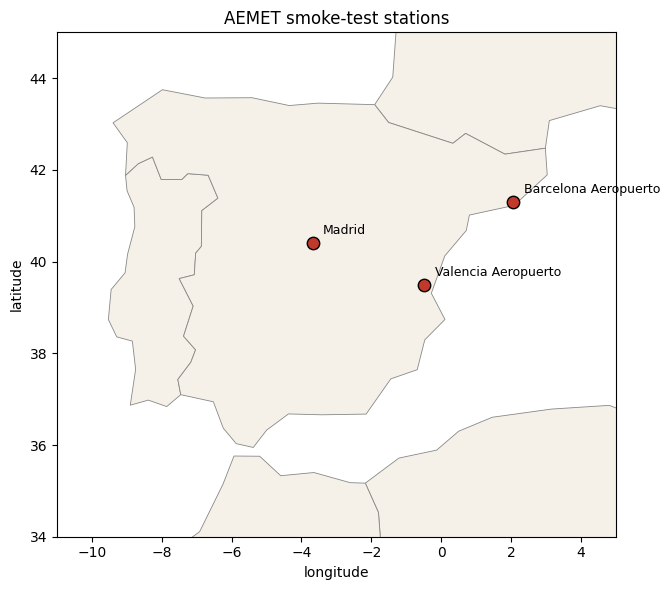

In [6]:
stations_gdf = archive.load_stations_geodataframe()
stations_picked = stations_gdf[stations_gdf["id"].isin(obs["station_id"].unique())]

# Natural Earth low-res world shapefile ships with geopandas.
try:
    world = gpd.read_file(
        "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    )
except Exception:
    # Offline fallback: read from the pyproj data dir if available
    # (avoids network in CI); otherwise just plot without a basemap.
    world = None

fig, ax = plt.subplots(figsize=(8, 6))
if world is not None:
    iberia = world.cx[-11:5, 34:45]
    iberia.plot(ax=ax, color="#f5f1e8", edgecolor="#888", linewidth=0.6)
stations_picked.plot(
    ax=ax,
    color="#c0392b",
    edgecolor="black",
    markersize=80,
    zorder=5,
)
for _, row in stations_picked.iterrows():
    ax.annotate(
        row["name"].split(",")[0].title(),
        xy=(row["lon"] + 0.3, row["lat"] + 0.2),
        fontsize=9,
    )
ax.set_xlim(-11, 5)
ax.set_ylim(34, 45)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("AEMET smoke-test stations")
plt.tight_layout()
plt.show()

## 6. Time series per variable

AEMET's monthly endpoint exposes ten value columns. What each one means:

| column | AEMET code | meaning |
|---|---|---|
| `air_temperature_daily_mean` | `tm_mes` | Monthly mean of daily mean temperature (°C) |
| `air_temperature_daily_min` | `tm_min` | Monthly mean of **daily minimum** temperature (°C). Sensitive to nighttime cooling and cold-air pooling. |
| `air_temperature_daily_max` | `tm_max` | Monthly mean of **daily maximum** temperature (°C). The classic heat-wave indicator. |
| `precipitation_amount` | `p_mes` | Total monthly precipitation (mm) |
| `wind_speed_daily_mean` | `w_med` | Monthly mean wind speed (m s⁻¹) |
| `wind_speed_of_gust_daily` | `w_racha` | Peak monthly wind gust — AEMET annotates it with the day of occurrence; our parser drops that suffix automatically. |
| `surface_pressure_hpa` | `q_med` | Monthly mean station pressure (hPa) |
| `surface_pressure_max_hpa` | `q_max` | Monthly pressure extreme (max) |
| `surface_pressure_min_hpa` | `q_min` | Monthly pressure extreme (min) |
| `sunshine_duration_daily` | `inso` | Sunshine duration — AEMET reports this inconsistently at monthly cadence; expect NaN for most mainland stations (use the `aemet_daily` preset for reliable sunshine). |

In [7]:
value_cols = [
    c for c in obs.columns if c not in {"station_id", "time", "lon", "lat", "geometry"}
]

# Pivot the long-format archive into a (time × station) wide table
# for easy matplotlib plotting.
wide = {
    col: obs.pivot_table(index="time", columns="station_id", values=col)
    for col in value_cols
}

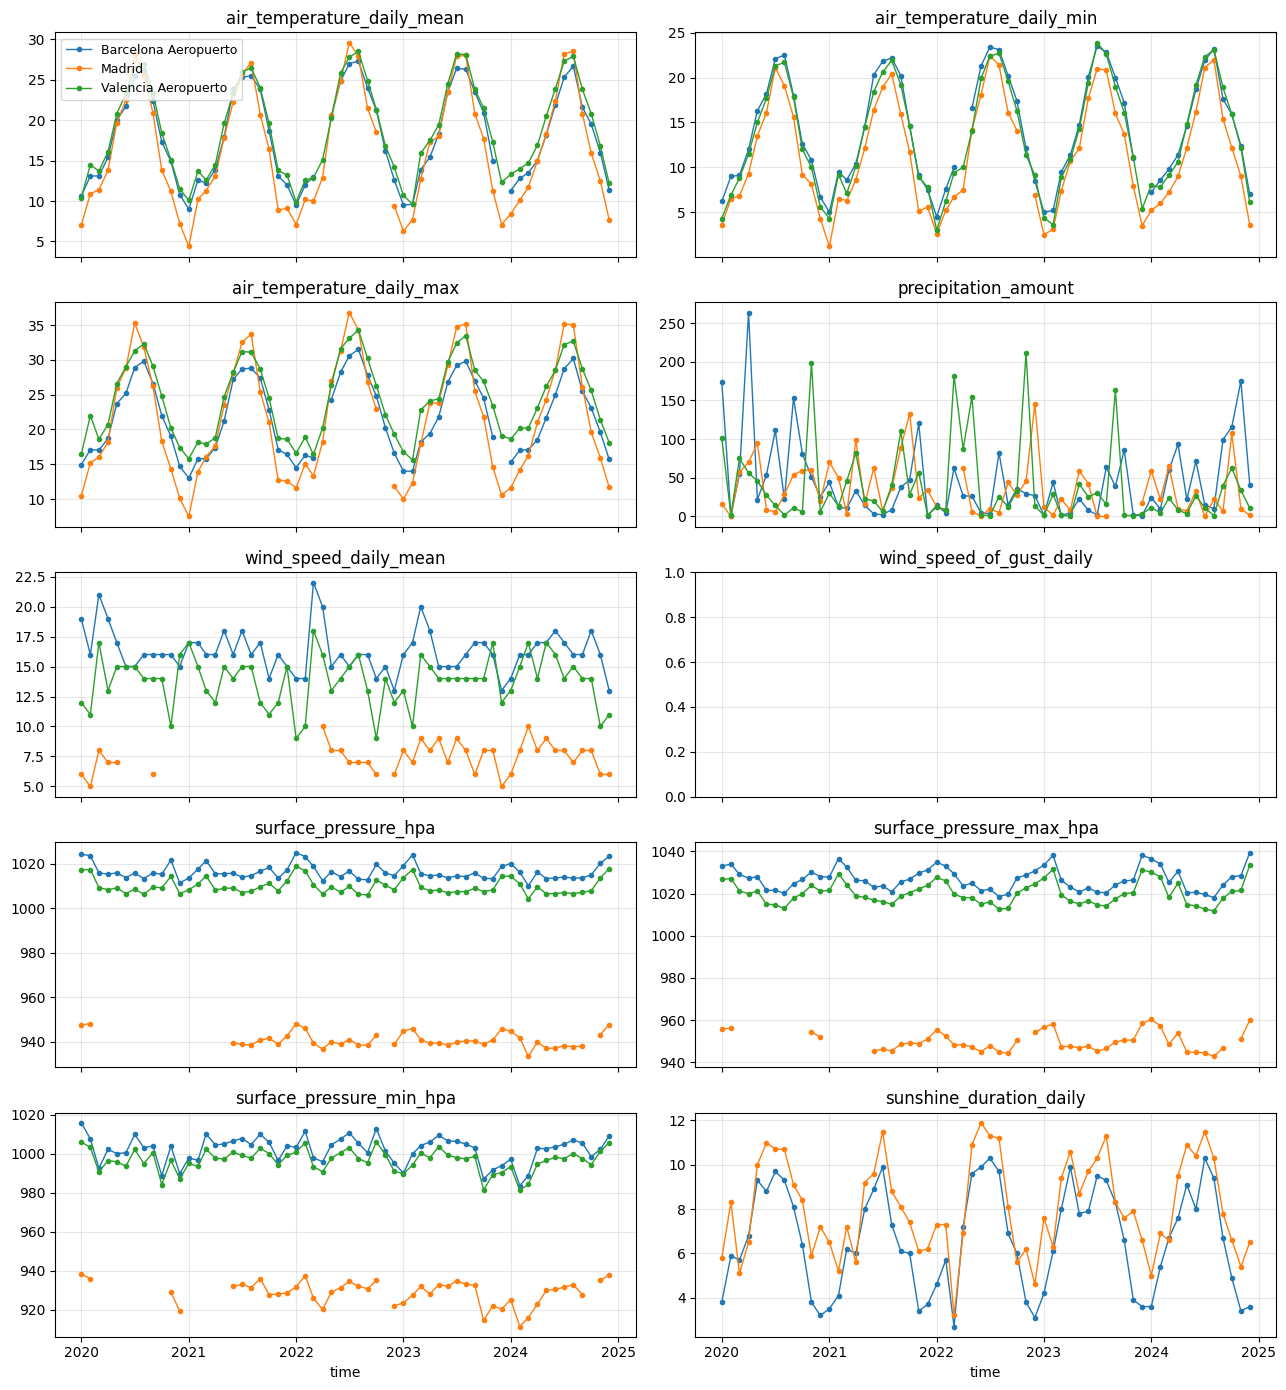

In [8]:
label_for_station = {s.id: s.name.split(",")[0].title() for s in picks}

fig, axes = plt.subplots(5, 2, figsize=(13, 14), sharex=True)
for ax, col in zip(axes.flat, value_cols):
    frame = wide[col]
    for sid in frame.columns:
        ax.plot(
            pd.to_datetime(frame.index),
            frame[sid].values,
            marker="o",
            markersize=3,
            linewidth=1.0,
            label=label_for_station.get(sid, sid),
        )
    ax.set_title(col)
    ax.grid(alpha=0.3)
    if col == value_cols[0]:
        ax.legend(loc="upper left", fontsize=9)
for ax in axes[-1]:
    ax.set_xlabel("time")
plt.tight_layout()
plt.show()

## 7. Sanity checks

A quick numerical check that the fetched values are physically sensible and that the time axis is complete.

In [9]:
summary = (
    obs.groupby("station_id")[
        [
            "air_temperature_daily_mean",
            "air_temperature_daily_min",
            "air_temperature_daily_max",
            "precipitation_amount",
            "sunshine_duration_daily",
        ]
    ]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)
print(summary)

           air_temperature_daily_mean                    \
                                count   mean  min   max   
station_id                                                
0076                               58  17.97  9.0  27.3   
3195                               59  16.43  4.4  29.6   
8414A                              60  18.81  9.6  28.5   

           air_temperature_daily_min                    \
                               count   mean  min   max   
station_id                                               
0076                              58  14.15  4.5  23.5   
3195                              59  11.40  1.2  22.4   
8414A                             60  13.35  3.0  23.9   

           air_temperature_daily_max                    precipitation_amount  \
                               count   mean   min   max                count   
station_id                                                                     
0076                              58  21.74  13.0  31.5 

- `air_temperature_daily_mean` bands should overlap: Madrid continental (cold winters / hot summers, wide range), Valencia + Barcelona coastal Mediterranean (milder range).
- `precipitation_amount` totals should be lowest in Valencia, highest at Retiro in the wet seasons — but with occasional heavy months on the coast.
- `sunshine_duration_daily` is expected to be mostly NaN at monthly cadence (AEMET quirk noted above).
- `count` on the sanity table should be 60 (12 months × 5 years) for each station, confirming the time axis has no gaps.